Epoch 1/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7701 - mae: 0.7130 - val_loss: 0.4796 - val_mae: 0.5539
Epoch 2/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4990 - mae: 0.5541 - val_loss: 0.3026 - val_mae: 0.4360
Epoch 3/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3860 - mae: 0.4729 - val_loss: 0.2368 - val_mae: 0.3868
Epoch 4/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3285 - mae: 0.4321 - val_loss: 0.2254 - val_mae: 0.3815
Epoch 5/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3177 - mae: 0.4170 - val_loss: 0.2101 - val_mae: 0.3695
Epoch 6/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2783 - mae: 0.3954 - val_loss: 0.2000 - val_mae: 0.3619
Epoch 7/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2485 - mae: 0.3750 - val_loss: 0.1788 - val_mae: 0.3413
Epoch 8/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2337 - mae: 0.3617 - val_loss: 0.1912 - val_mae: 0.3525
Epoch 9/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - lo

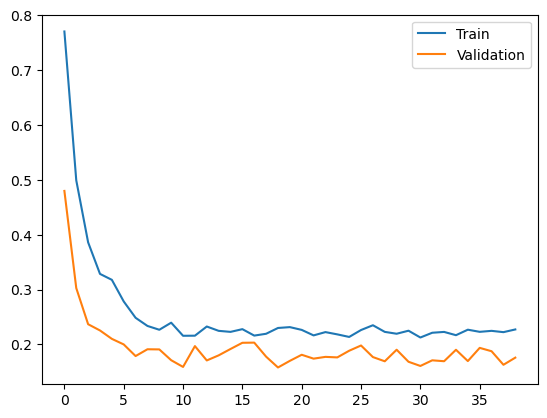

In [3]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
  
# data fetching
data = pd.read_csv("Dataset.csv")
 
X = data.iloc[:, :6].values
y = data.iloc[:, 6:7].values
 
# train-test splitting the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
# feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
 
scy = StandardScaler()
y_train = scy.fit_transform(y_train.reshape(-1, 1))
y_test = scy.transform(y_test.reshape(-1, 1))
 
# building an ann model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import Dropout
 
# initializing the ANN
Classifier = Sequential()
Classifier.add(Input(shape=(X_train.shape[1],)))          # FIX: explicit input layer
Classifier.add(Dense(units=11, activation='relu'))
Classifier.add(Dense(units=7, activation='relu'))
Classifier.add(Dropout(0.2))
Classifier.add(Dense(units=6, activation='relu'))
Classifier.add(Dropout(0.2))                                # FIX: 0.3 -> 0.2, too aggressive for a 6-unit layer
Classifier.add(Dense(1, activation='linear'))
 
Classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)
 
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True,     # FIX: was False
    start_from_epoch=0,
)
 
model_history = Classifier.fit(
    X_train, y_train, batch_size=10, epochs=50,
    validation_split=0.2, verbose=1, callbacks=[early_stopping]
)
 
loss, mae = Classifier.evaluate(X_test, y_test)
print(f"Test MAE (scaled): {mae:.4f}")
 
from sklearn.metrics import r2_score
y_pred = Classifier.predict(X_test)
y_pred_actual = scy.inverse_transform(y_pred)
y_test_actual = scy.inverse_transform(y_test)
 
r2 = r2_score(y_test_actual, y_pred_actual)
print(f"R^2 (forecast accuracy): {r2*100:.2f}%")
 
# predicting on new data
new_data = np.array([[45.0, 84, 120.0, 60.0, 39, 0.85]])
scaled_data = sc.transform(new_data)
prediction = Classifier.predict(scaled_data)
prediction_actual = scy.inverse_transform(prediction)
print(f"Predicted Power Consumption: {prediction_actual[0][0]:.2f} units")
 
# optimizing the feature based on given power consumption
from scipy.optimize import minimize
 
def optimize_features(desired_power, Classifier, sc, scy, feature_bounds):
    def objective(features):
        features = np.array(features).reshape(1, -1)
        normalized_features = sc.transform(features)
        prediction_scaled = Classifier.predict(normalized_features, verbose=0)
        prediction_actual = scy.inverse_transform(prediction_scaled)
        return np.abs(desired_power - prediction_actual[0][0])
 
    initial_guess = [np.mean(b) for b in feature_bounds]
    result = minimize(objective, initial_guess, bounds=feature_bounds)
    return result.x
 
feature_bounds = [
    (20, 60), (40, 100), (50, 200), (30, 90), (25, 35), (0.7, 0.85)
]
 
desired_power = 450.0
optimized_features = optimize_features(desired_power, Classifier, sc, scy, feature_bounds)
print(f"\nOptimized features for {desired_power} units of power consumption:")
print(f"Temperature: {optimized_features[0]:.2f}")
print(f"MachineUtilization: {optimized_features[1]:.2f}")
print(f"ProductionRate: {optimized_features[2]:.2f}")
print(f"Humidity: {optimized_features[3]:.2f}")
print(f"LoadCurrent: {optimized_features[4]:.2f}")
print(f"PowerFactor: {optimized_features[5]:.2f}")

plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.legend(['Train','Validation'])
 
import joblib
Classifier.save("industriq_model.keras")
joblib.dump(sc, "scaler_x.joblib")
joblib.dump(scy, "scaler_y.joblib")
print("\nSaved model + scalers successfully.")